In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

In [2]:

local_file = "JWST_AGN_catalog_v1.0.0.csv"
if os.path.exists(local_file):
    catalogue = pd.read_csv(local_file)
else:
    url = "https://github.com/VirginiaLenk1/AGNs-in-eJWST/releases/download/AGN_catalogue/JWST_AGN_catalog_v1.0.0.csv"
    catalogue = pd.read_csv(url)
    catalogue.to_csv(local_file, index=False)



/var/folders/wq/wms_s60j3rd4ght9pgj3l7yr0000gn/T/ipykernel_2895/3140721760.py:3: DtypeWarning: Columns (0: TSOVISIT, 1: eJWST Name, 2: objType (eJWST), 3: Milliquas Name, 4: XName, 5: RName, 6: zType (Milliquas), 7: zRef (Milliquas), 8: objType (Milliquas), 9: MaNGA Name, 10: zType (MaNGA), 11: zRef (MaNGA), 12: objType (MaNGA), 13: eFEDS Name, 14: zType (eFEDS), 15: zRef (eFEDS), 16: Stripe Name, 17: zType (Stripe), 18: zRef (Stripe), 19: objType (Stripe), 20: CDFS Name, 21: zType (CDFS), 22: zRef (CDFS), 23: objType (CDFS), 24: BASS Name, 25: zType (BASS), 26: zRef (BASS), 27: objType (BASS), 28: Veroncat Name, 29: zType (Veroncat), 30: zRef (Veroncat), 31: objType (Veroncat), 32: Rosat Name, 33: zType (Rosat), 34: zRef (Rosat), 35: objType (Rosat), 36: Gaia Name, 37: Swiftbat Name) have mixed types. Specify dtype option on import or set low_memory=False.
  catalogue = pd.read_csv(local_file)


In [3]:
# Inspect first few rows
catalogue.head()

# Example: filter for spectroscopic redshifts (any code starting with 'S')
specz = catalogue[catalogue["zType"].str.startswith('S', na=False)]
print(f"Number of spectroscopic AGNs: {len(specz)}")



Number of spectroscopic AGNs: 287390


In [4]:
# Example: filter for photometric redshifts (any code starting with 'P')
photz = catalogue[catalogue["zType"].str.startswith('P', na=False)]
print(f"Number of photometric AGNs: {len(photz)}")



Number of photometric AGNs: 8128


In [5]:
# Example: filter low redshift, MIRI observations that are targeted 
filtered_df = catalogue[
    (catalogue["z"] < 0.1) &
    (catalogue["Instrument"].str.contains("MIRI", case=False, na=False)) &
    (catalogue["Targeted"] == True)
]
filtered_df

,Name,"RA (J2000, deg)","Dec (J2000, deg)",objType,Ref,z,zType,zRef,zNED,Observation ID,...,z (Rosat),zType (Rosat),zRef (Rosat),objType (Rosat),Gaia Name,RA (Gaia),Dec (Gaia),Swiftbat Name,RA (Swiftbat),Dec (Swiftbat)
217,3C-305,222.339969,63.270503,Active galactic nuclei; Radio galaxies; Radio ...,eJWST,0.041706,SLS,2016SDSSD.C...0000:,y,jw04237-o002_t004_miri_f1130w,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
218,3C-305,222.339969,63.270503,Active galactic nuclei; Radio galaxies; Radio ...,eJWST,0.041706,SLS,2016SDSSD.C...0000:,y,jw04237-o002_t004_miri_f770w,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
219,3C-305,222.352578,63.247281,Active galactic nuclei; Radio galaxies; Radio ...,eJWST,0.041706,SLS,2016SDSSD.C...0000:,y,jw04237-o003_t003_miri_ch1-shortmediumlong,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
220,3C-305,222.352578,63.247281,Active galactic nuclei; Radio galaxies; Radio ...,eJWST,0.041706,SLS,2016SDSSD.C...0000:,y,jw04237-o003_t003_miri_ch2-shortmediumlong,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
221,3C-305,222.352578,63.247281,Active galactic nuclei; Radio galaxies; Radio ...,eJWST,0.041706,SLS,2016SDSSD.C...0000:,y,jw04237-o003_t003_miri_ch3-shortmediumlong,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
407878,XN11523,37.519417,-5.137250,Active galactic nuclei; Active galaxies; Quasars,eJWST,-1.000000,NaN,NaN,n,jw03158-o008_t008_miri_ch4-short,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
407879,XN8144,34.374792,-4.306572,Active galactic nuclei; Active galaxies; Quasars,eJWST,-1.000000,NaN,NaN,n,jw03158-o007_t007_miri_ch1-short,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
407880,XN8144,34.374792,-4.306572,Active galactic nuclei; Active galaxies; Quasars,eJWST,-1.000000,NaN,NaN,n,jw03158-o007_t007_miri_ch2-short,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
407881,XN8144,34.374792,-4.306572,Active galactic nuclei; Active galaxies; Quasars,eJWST,-1.000000,NaN,NaN,n,jw03158-o007_t007_miri_ch3-short,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


[ True False]
bool
Targeted: 1079 | con z: 1079
Non-targeted: 2514 | con z: 2514


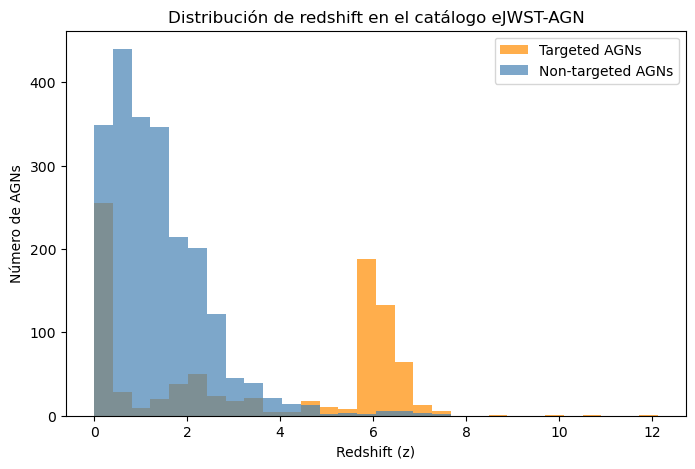

In [6]:


df = catalogue

# --- Verificación 1: tipo de dato de la columna Targeted ---
print(df["Targeted"].unique())
print(df["Targeted"].dtype)

# Si aparece como string, conviértela explícitamente:
if df["Targeted"].dtype == object:
    df["Targeted"] = df["Targeted"].map({"True": True, "False": False})

targeted_unique = df[df["Targeted"] == True].drop_duplicates(subset="Name")
non_targeted_unique = df[df["Targeted"] == False].drop_duplicates(subset="Name")

# --- Verificación 2: cuántos objetos hay realmente en cada grupo ---
print("Targeted:", len(targeted_unique), "| con z:", targeted_unique["z"].notna().sum())
print("Non-targeted:", len(non_targeted_unique), "| con z:", non_targeted_unique["z"].notna().sum())

# --- Fix: usar los MISMOS bins para ambos histogramas ---
z_all = df["z"].dropna()
bins = np.linspace(0, z_all.max(), 31)  # 30 bins compartidos, mismo rango

plt.figure(figsize=(8, 5))
plt.hist(targeted_unique["z"].dropna(), bins=bins, alpha=0.7,
         label="Targeted AGNs", color="darkorange")
plt.hist(non_targeted_unique["z"].dropna(), bins=bins, alpha=0.7,
         label="Non-targeted AGNs", color="steelblue")
plt.xlabel("Redshift (z)")
plt.ylabel("Número de AGNs")
plt.legend()
plt.title("Distribución de redshift en el catálogo eJWST-AGN")
plt.show()

In [7]:


# --- Búsqueda flexible por nombre ---
# Normalizamos: quitamos espacios y guiones, todo en mayúsculas
def normalizar(nombre):
    return str(nombre).upper().replace(" ", "").replace("-", "").replace("_", "")

nombre_buscado = normalizar("UGC 8782")

# Buscamos coincidencia en la columna principal "Name"
mask = df["Name"].apply(normalizar).str.contains(nombre_buscado, na=False)
resultado = df[mask]

print(f"Observaciones encontradas para 3C 293: {len(resultado)}")

if len(resultado) == 0:
    print("No se encontró en la columna 'Name'. Puede estar bajo otro alias")
    print("(ej. eJWST Name, o el nombre dado por alguno de los catálogos externos).")
else:
    # --- Info del objeto en sí (única, sin repetir por cada observación) ---
    info_objeto = resultado[[
        "Name", "RA (J2000, deg)", "Dec (J2000, deg)", "objType",
        "Ref", "z", "zType", "zRef", "Targeted"
    ]].drop_duplicates(subset="Name")
    print("\n--- Información del objeto ---")
    print(info_objeto.T)  # .T para verla en formato lista vertical

    # --- Tabla completa con todas las columnas disponibles ---
    print(f"\n--- Tabla completa de características para 3C 293 ({len(resultado)} filas) ---")
    from IPython.display import display
    display(resultado.reset_index(drop=True))

Observaciones encontradas para 3C 293: 9

--- Información del objeto ---
                               396887
Name                         UGC 8782
RA (J2000, deg)             208.07452
Dec (J2000, deg)             31.44625
objType                    AGN-NL-R-X
Ref                          Millquas
z                            0.045194
zType                             SLS
zRef              2016SDSSD.C...0000:
Targeted                         True

--- Tabla completa de características para 3C 293 (9 filas) ---


,Name,"RA (J2000, deg)","Dec (J2000, deg)",objType,Ref,z,zType,zRef,zNED,Observation ID,...,z (Rosat),zType (Rosat),zRef (Rosat),objType (Rosat),Gaia Name,RA (Gaia),Dec (Gaia),Swiftbat Name,RA (Swiftbat),Dec (Swiftbat)
0,UGC 8782,208.07452,31.44625,AGN-NL-R-X,Millquas,0.045194,SLS,2016SDSSD.C...0000:,y,jw01928-c1005_t008_miri_ch1-shortlong,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,UGC 8782,208.07452,31.44625,AGN-NL-R-X,Millquas,0.045194,SLS,2016SDSSD.C...0000:,y,jw01928-c1005_t008_miri_ch2-shortlong,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,UGC 8782,208.07452,31.44625,AGN-NL-R-X,Millquas,0.045194,SLS,2016SDSSD.C...0000:,y,jw01928-c1005_t008_miri_ch3-shortlong,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,UGC 8782,208.07452,31.44625,AGN-NL-R-X,Millquas,0.045194,SLS,2016SDSSD.C...0000:,y,jw01928-c1005_t008_miri_ch4-shortlong,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,UGC 8782,208.07452,31.44625,AGN-NL-R-X,Millquas,0.045194,SLS,2016SDSSD.C...0000:,y,jw01928-o007_t007_nirspec_g235h-f170lp,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,UGC 8782,208.07452,31.44625,AGN-NL-R-X,Millquas,0.045194,SLS,2016SDSSD.C...0000:,y,jw01928-o008_t008_miri_ch1-shortlong,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,UGC 8782,208.07452,31.44625,AGN-NL-R-X,Millquas,0.045194,SLS,2016SDSSD.C...0000:,y,jw01928-o008_t008_miri_ch2-shortlong,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,UGC 8782,208.07452,31.44625,AGN-NL-R-X,Millquas,0.045194,SLS,2016SDSSD.C...0000:,y,jw01928-o008_t008_miri_ch3-shortlong,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,UGC 8782,208.07452,31.44625,AGN-NL-R-X,Millquas,0.045194,SLS,2016SDSSD.C...0000:,y,jw01928-o008_t008_miri_ch4-shortlong,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
